# Similaridade de reviews de clientes

In [1]:
from ipywidgets import Widget
from ipywidgets.widgets.widget import Widget
from ipywidgets import Widget
from IPython.display import display

Widget.widgets = {}

display(Widget())

Widget()

In [ ]:
# !pip install gensim unidecode stanza gradio

In [ ]:
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import numpy as np
from functools import partial
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument
import re
import unidecode
import stanza

In [ ]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
stanza.download('pt')

nlp = stanza.Pipeline('pt', processors='tokenize,lemma',
                      use_gpu=False, batch_size=64,
                      n_process=4)

INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: pt (Portuguese) ...


INFO:stanza:Downloaded file to /root/stanza_resources/pt/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: pt (Portuguese):
| Processor | Package         |
-------------------------------
| tokenize  | bosque          |
| mwt       | bosque          |
| lemma     | bosque_nocharlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: lemma
INFO:stanza:Done loading processors!


In [ ]:
url = 'https://raw.githubusercontent.com/alura-cursos/NLP-trabalhando-similaridade-sentencas/refs/heads/main/reviews_zoop.csv'
df = pd.read_csv(url)

df.tail()

,nota_review,review
39457,5,Entregou dentro do prazo. O produto chegou em ...
39458,3,"O produto não foi enviado com NF, não existe v..."
39459,5,"Excelente mochila, entrega super rápida. Super..."
39460,1,Solicitei a compra de uma capa de retrovisor c...
39461,1,"meu produto chegou e ja tenho que devolver, po..."


In [ ]:
word_tokenize_pt = partial(word_tokenize, language='portuguese')

In [ ]:
model = Word2Vec(sentences = df['review'].apply(word_tokenize_pt),
                 vector_size=100, min_count=1, window=5,
                 workers=1, seed=45)

In [ ]:
model.wv.most_similar('entrega')

[('Entrega', 0.7526029944419861),
 ('entregue', 0.7109662294387817),
 ('compra', 0.6985824108123779),
 ('chegou', 0.6755236983299255),
 ('entregou', 0.6542965769767761),
 ('envio', 0.6249788403511047),
 ('cadastrado', 0.6161651611328125),
 ('Chegou', 0.6127404570579529),
 ('preparar', 0.6111896634101868),
 ('mercadoria', 0.6036772727966309)]



> O Word2Vec é uma ferramenta que permite compreender o significado das palavras com base no contexto em que elas aparecem em textos. Introduzido no artigo Efficient Estimation of Word Representations in Vector Space em 2013 por pesquisadores do Google, o Word2Vec permite que computadores reconheçam palavras que têm significados parecidos e as “aproximem” dentro de um espaço matemático, chamado de espaço vetorial.

> A lógica por trás do Word2Vec é simples: palavras que aparecem em contextos semelhantes provavelmente têm significados parecidos. Imagine as palavras ”gato”, ”filhote” e ”gatiinho”. Elas podem ser usadas em contextos similares, como em frases com palavras como *”fofinho" ”bonito” e ”adorável”. Por isso, o Word2Vec posiciona essas palavras próximas umas das outras em seu mapa vetorial de palavras - o espaço vetorial. Isso só funciona porque o Word2Vec consegue representar cada palavra por um conjunto de números, chamados de vetores, que preservam essas semelhanças.



In [ ]:
df['review_token'] = df['review'].apply(word_tokenize_pt)

df.tail(3)

,nota_review,review,review_token
39459,5,"Excelente mochila, entrega super rápida. Super...","[Excelente, mochila, ,, entrega, super, rápida..."
39460,1,Solicitei a compra de uma capa de retrovisor c...,"[Solicitei, a, compra, de, uma, capa, de, retr..."
39461,1,"meu produto chegou e ja tenho que devolver, po...","[meu, produto, chegou, e, ja, tenho, que, devo..."


In [ ]:
df_tag = [TaggedDocument(words=linha['review_token'], tags=[str(i)]) for i, linha in df.iterrows()]

df_tag

[TaggedDocument(words=['Recebi', 'bem', 'antes', 'do', 'prazo', 'estipulado', '.'], tags=['0']),
 TaggedDocument(words=['Parabéns', 'lojas', 'Zoop', 'adorei', 'comprar', 'pela', 'Internet', 'seguro', 'e', 'prático', 'Parabéns', 'a', 'todos', 'feliz', 'Páscoa'], tags=['1']),
 TaggedDocument(words=['aparelho', 'eficiente', '.', 'no', 'site', 'a', 'marca', 'do', 'aparelho', 'esta', 'impresso', 'como', '3desinfector', 'e', 'ao', 'chegar', 'esta', 'com', 'outro', 'nome', '...', 'atualizar', 'com', 'a', 'marca', 'correta', 'uma', 'vez', 'que', 'é', 'o', 'mesmo', 'aparelho'], tags=['2']),
 TaggedDocument(words=['Mas', 'um', 'pouco', ',', 'travando', '...', 'pelo', 'valor', 'ta', 'Boa', '.'], tags=['3']),
 TaggedDocument(words=['Vendedor', 'confiável', ',', 'produto', 'ok', 'e', 'entrega', 'antes', 'do', 'prazo', '.'], tags=['4']),
 TaggedDocument(words=['GOSTARIA', 'DE', 'SABER', 'O', 'QUE', 'HOUVE', ',', 'SEMPRE', 'RECEBI', 'E', 'ESSA', 'COMPRA', 'AGORA', 'ME', 'DECPCIONOU'], tags=['5']),
 T

* **vector_size**=100: define o tamanho do vetor numérico gerado em 100.

* **min_count**=2: ignora palavras que aparecem menos de 2 vezes.

* **window**=2: especifica o contexto de análise como 2.

* **workers**=1: define o número de CPUs usadas como 1.

* **seed**=45: garante reprodutibilidade.

* **epochs**=20: número de vezes que o modelo rodará o treinamento.

In [ ]:
model = Doc2Vec(df_tag, vector_size=100, min_count=2, window=2,
                 workers=1, seed=45, epochs=20)

In [ ]:
# Exemplo de inferência
vetor_inferido = model.infer_vector(['entrega'])
vetor_inferido

array([-1.70943156e-01, -3.75562944e-02,  4.49156240e-02, -4.24942002e-02,
        5.23195453e-02,  8.89081210e-02, -6.18354008e-02, -7.50278495e-03,
       -6.77398127e-03, -8.65676180e-02, -8.71190280e-02,  7.91766867e-03,
       -1.16021253e-01,  2.49120761e-02, -5.53794168e-02, -8.36805478e-02,
        2.25803989e-04,  5.45161590e-02, -1.41163394e-02,  4.24326770e-03,
        2.30208114e-02, -4.86382730e-02,  6.54490814e-02,  2.23185737e-02,
        7.64473947e-03, -5.24675925e-05, -1.39581993e-01, -5.64440899e-02,
       -2.61710566e-02, -5.51618263e-02,  8.25005025e-02,  3.00726034e-02,
        2.18961537e-02,  7.28161484e-02,  4.37341928e-02, -1.65199004e-02,
       -8.67533609e-02,  1.47780925e-01, -1.18379548e-01, -1.62340831e-02,
       -4.41895705e-03,  1.18407309e-02,  2.55399961e-02, -7.35243261e-02,
       -6.92148507e-02, -3.98389325e-02,  2.73070186e-02, -7.37743510e-04,
       -8.19418430e-02, -1.77766643e-02,  3.73559557e-02,  7.46070780e-03,
        9.12952237e-03, -

In [ ]:
frases_similares = model.dv.most_similar([vetor_inferido],topn=5)
frases_similares

[('24666', 0.8555141091346741),
 ('9304', 0.8535730242729187),
 ('33496', 0.8496885299682617),
 ('7314', 0.8435733318328857),
 ('38093', 0.8349294662475586)]

In [ ]:
for idx, similaridade in frases_similares:
    print(f"Review: {df.iloc[int(idx)]['review']} - Similaridade: {similaridade:.4f}")

Review: entrega antes do prazo - Similaridade: 0.8555
Review: entrega no prazo. - Similaridade: 0.8536
Review: Ainda estou esperando a entrega!  - Similaridade: 0.8497
Review: entrega antes do prazo. - Similaridade: 0.8436
Review: Ainda estou aguardando a entrega - Similaridade: 0.8349


In [ ]:
def tratamento_inicial(text):
  text = re.sub(r'\W', ' ', text.lower())
  tokens = word_tokenize_pt(text)
  stop_words = set(stopwords.words('portuguese'))
  #precisamos da palavra 'nao'
  stop_words.discard('não')
  stop_words.discard('nao')

  return ' '.join([w for w in tokens if w not in stop_words])

In [ ]:
df['tratamento_1'] = df['review'].apply(tratamento_inicial)

df.tail()

,nota_review,review,review_token,tratamento_1
39457,5,Entregou dentro do prazo. O produto chegou em ...,"[Entregou, dentro, do, prazo, ., O, produto, c...",entregou dentro prazo produto chegou condições...
39458,3,"O produto não foi enviado com NF, não existe v...","[O, produto, não, foi, enviado, com, NF, ,, nã...",produto não enviado nf não existe venda nf cer...
39459,5,"Excelente mochila, entrega super rápida. Super...","[Excelente, mochila, ,, entrega, super, rápida...",excelente mochila entrega super rápida super r...
39460,1,Solicitei a compra de uma capa de retrovisor c...,"[Solicitei, a, compra, de, uma, capa, de, retr...",solicitei compra capa retrovisor celta prisma ...
39461,1,"meu produto chegou e ja tenho que devolver, po...","[meu, produto, chegou, e, ja, tenho, que, devo...",produto chegou ja devolver pois defeito não se...


In [ ]:
df['review'][11], df['tratamento_1'][11]

('Sempre compro pela Internet e a entrega ocorre antes do prazo combinado, que acredito ser o prazo máximo. No  o prazo máximo já se esgotou e ainda não recebi o produto.',
 'sempre compro internet entrega ocorre antes prazo combinado acredito prazo máximo prazo máximo esgotou ainda não recebi produto')

In [ ]:
sem_acentos = [unidecode.unidecode(text) for text in df['tratamento_1']]

df['tratamento_2'] = sem_acentos
df['tratamento_2'].tail(2)

,tratamento_2
39460,solicitei compra capa retrovisor celta prisma ...
39461,produto chegou ja devolver pois defeito nao se...


In [ ]:
df['review_token'] = df['tratamento_2'].apply(word_tokenize_pt)
dados_tag = [TaggedDocument(words=linha['review_token'], tags=[str(i)]) for i, linha in df.iterrows()]
model = Doc2Vec(df_tag, vector_size=100, min_count=2, window=2,
                 workers= 1, seed=45, epochs=20)
frases_similares = model.dv.most_similar([model.infer_vector(['entrega'])],topn=5)
for idx, similaridade in frases_similares:
    print(f"Review: {df.iloc[int(idx)]['tratamento_2']} - Similaridade: {similaridade:.4f}")

Review: entrega antes prazo - Similaridade: 0.8555
Review: entrega prazo - Similaridade: 0.8536
Review: ainda esperando entrega - Similaridade: 0.8497
Review: entrega antes prazo - Similaridade: 0.8436
Review: ainda aguardando entrega - Similaridade: 0.8349


## Correção nos dados

In [ ]:
df['tratamento_2'][3319]

'simplismeente ameiii'

In [ ]:
df = df.drop_duplicates(subset=['tratamento_2'])

df = df[df['tratamento_2'] != '']

def normalizar_repeticoes(text):
  return re.sub(r'(?!rr|ss)(.)\1+', r'\1', text)

df['tratamento_3'] = df['tratamento_2'].apply(normalizar_repeticoes)

In [ ]:
df['tratamento_3'][3319]

'simplismente amei'

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
def lematizar_texto(textos):
  texto_lematizados = []

  for texto in textos:
    doc_frase = nlp(texto)
    frase_lematizada = ' '.join([palavra.lemma for frase in doc_frase.sentences for palavra in frase.words])
    texto_lematizados.append(frase_lematizada)

  return texto_lematizados

In [ ]:
#Exemplo de uso de lematização
textos = ['gostei muito experiencia comprar',
          'minha filha gostou produto',
          'compra foi facil compra rapida']

lematizar_texto(textos)

['gostar muito experiencia comprar',
 'meu filha gostar produto',
 'compra ser facil compra rapida']

In [ ]:
df['tratamento_4'] = lematizar_texto(df['tratamento_3'])

In [ ]:
df['tratamento_4']

,tratamento_4
0,recebi bem antes prazo estipulado
1,parabem loja zop adorei comprar internet segur...
2,aparelho eficiente site marca aparelho imprimi...
3,pouco travar valor to bom
4,vendedor confiavel produto ok entregar antes p...
...,...
31469,entregar dentro prazo produto chegar condicoe ...
31470,produto nao enviado em f nao existir venda em ...
31471,excelente mochila entregar super rapida super ...
31472,solicitei compra capa retrovisor celta prisma ...


> **Tokenização**

A tokenização é o primeiro passo no pré-processamento de texto, onde as frases são divididas em unidades menores chamadas “tokens”. Esses tokens podem ser palavras individuais, frases curtas ou até mesmo subpalavras, dependendo da abordagem adotada. Além de separar as palavras, esse processo geralmente remove pontuação e caracteres especiais que não contribuem para o significado do texto. Por exemplo, a frase ”Eu amo NLP!” é dividida em tokens ["Eu", "amo", "NLP"]. É importante lembrar que, em casos de palavras compostas, como “arco-íris” ou “bate-papo”, essas combinações possuem significados próprios e podem requerer um tratamento especial na tokenização.

> **Remoção de Stop Words**

Stop words são palavras de alta frequência, como “e”, “o”, “de”, que aparecem em quase todos os textos mas não acrescentam valor semântico significativo para muitos modelos. A remoção dessas palavras ajuda a reduzir o ruído e mantém apenas os termos mais relevantes, facilitando o desempenho do modelo. Bibliotecas como NLTK ou spaCy oferecem listas de stop words para diversos idiomas, e é possível personalizar essas listas conforme a necessidade, adicionando ou removendo palavras para um ajuste mais preciso do modelo.

> **Normalização: Minúsculas e Remoção de Pontuações**

Normalizar o texto colocando tudo em minúsculas garante consistência, evitando que “Loja” e “loja” sejam tratados como tokens diferentes. Além disso, a remoção de pontuação, como vírgulas, pontos e pontos de interrogação, é uma prática comum, especialmente em análises onde esses sinais não alteram o significado. Isso torna o texto mais limpo para o modelo e evita resultados ruins.

> **Stemming e Lematização**

Tanto o stemming quanto a lematização são técnicas usadas para reduzir palavras à sua forma base, mas com abordagens diferentes. O Stemming simplifica palavras para suas raízes por meio de regras, removendo sufixos e prefixos. Por exemplo, “amando”, “amada” e “amar” podem ser reduzidos a “am”. No entanto, essa técnica pode ser um pouco agressiva, levando a resultados como “jogadores” se tornando “jog” em vez de “jogar”.

Já a Lematização leva em conta a estrutura gramatical e reduz as palavras à sua forma base, ou lema, com base no significado. Por exemplo, palavras como “correu” e “correndo” seriam convertidas para “correr”. A lematização é mais precisa, mas exige que o modelo tenha conhecimento do contexto da palavra, como se ela é um verbo ou substantivo. Para implementações, bibliotecas como spaCy e NLTK oferecem suporte para ambas as técnicas e stanza tem suporte para lematização.

## Otimizando o Doc2Vec

In [ ]:
df_lem = df.drop_duplicates(subset=['tratamento_4'])

df_lem.reset_index(drop=True, inplace=True)

In [ ]:
df_lem['review_token'] = df_lem['tratamento_4'].apply(word_tokenize_pt)
dados_tag = [TaggedDocument(words=linha['review_token'], tags=[str(i)]) for i, linha in df_lem.iterrows()]

modelo = Doc2Vec(dados_tag, vector_size=100, min_count=2, window=2,
                 workers= 1, seed=45, epochs=20)

frases_similares = modelo.dv.most_similar([modelo.infer_vector(['entrega'])],topn=5)

for idx, similaridade in frases_similares:
    print(f"Review: {df_lem.iloc[int(idx)]['tratamento_4']} - Similaridade: {similaridade:.4f}")

/tmp/ipython-input-31-256029232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lem['review_token'] = df_lem['tratamento_4'].apply(word_tokenize_pt)


Review: entrega demorando - Similaridade: 0.9123
Review: ultimamente atrasar entrega - Similaridade: 0.8824
Review: gostar entrega rapida - Similaridade: 0.8778
Review: muito desencontro entrega produto - Similaridade: 0.8717
Review: pedido chegar faltando item - Similaridade: 0.8688


In [ ]:
model = Doc2Vec(vector_size=300, min_count=2, window=5,
                 workers= 1, seed=45, epochs=20)

model.build_vocab(dados_tag)
model.train(dados_tag, total_examples=model.corpus_count, epochs=model.epochs)

In [ ]:
frases_similares = model.dv.most_similar([model.infer_vector(['entrega'])],topn=5)

for idx, similaridade in frases_similares:
    print(f"Review: {df_lem.iloc[int(idx)]['tratamento_1']} - Similaridade: {similaridade:.4f}")

Review: ultimamente atrasando entregas - Similaridade: 0.9001
Review: sempre bem atendido - Similaridade: 0.8818
Review: faltou itens - Similaridade: 0.8753
Review: produtos certos achei deveriam entregues juntos compra achei pouco demorada entrega - Similaridade: 0.8745
Review: recebi item pedido - Similaridade: 0.8731


O Doc2Vec, modelo que utilizamos até agora no nosso projeto, gera vetores dos textos, o que também chamamos de embeddings. Embeddings são representações numéricas de palavras ou frases em um espaço vetorial multidimensional, permitindo que computadores compreendam relações semânticas de maneira eficaz.

Diferente da tokenização, que converte o texto em unidades menores (tokens) e os mapeia para índices numéricos fixos, os embeddings atribuem coordenadas a esses tokens, posicionando-os em um espaço vetorial de forma que elementos semanticamente similares fiquem próximos.

A construção dos embeddings pelo Doc2Vec se dá através de um processo de treinamento que envolve contextos de palavras e o próprio documento. Existem duas abordagens principais no Doc2Vec: PV-DM (Distributed Memory) e PV-DBOW (Distributed Bag of Words). Ambas as abordagens treinam um modelo para prever palavras com base em contextos e também para associar cada documento a um vetor que reflete seu conteúdo geral.

No final, esses vetores se tornam embeddings que representam semanticamente o documento completo em um espaço multidimensional, de forma que a proximidade entre eles reflete sua similaridade de significado. Por exemplo, textos como “meu cachorro” e “meu gato fofo” podem ser colocados perto um do outro, pois ambos se referem a animais de estimação, enquanto uma frase como “eu fui ao banco” estaria mais distante, indicando um contexto diferente.

A similaridade entre esses vetores é medida com técnicas como a distância euclidiana ou a similaridade de cosseno. Essas medidas indicam quão próximas ou distantes duas palavras estão no espaço vetorial, refletindo sua semelhança semântica.

A Norma L2, também conhecida como Distância Euclidiana, é uma medida matemática amplamente usada para calcular a distância entre dois pontos em um espaço vetorial. Na prática, ela mede o “caminho mais curto” entre dois vetores, o que faz dela uma escolha comum para avaliar similaridades em tarefas de machine learning e NLP.

A distância entre dois pontos no plano pode ser calculada pela fórmula da hipotenusa, uma aplicação direta do Teorema de Pitágoras como mostrado na figura abaixo:

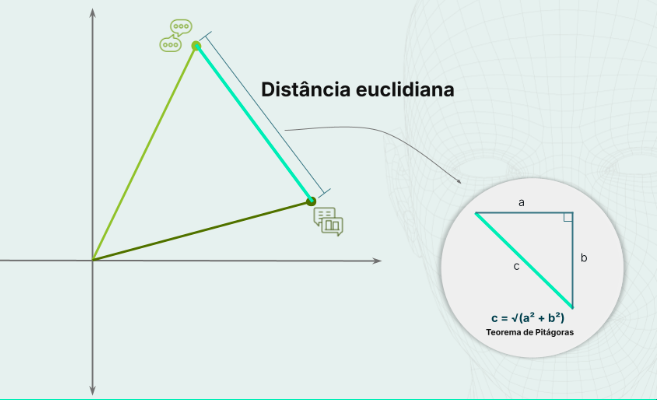

A mesma lógica pode ser estendida a espaços de dimensões superiores, como aqueles utilizados em embeddings de palavras ou documentos. Por exemplo, se temos dois vetores de embeddings em um espaço multidimensional, a fórmula continua se aplicando, calculando a raiz quadrada da soma dos quadrados das diferenças entre cada componente dos vetores.

Essa medida vai representar de forma intuitiva a proximidade entre pontos: quanto menor a distância, mais próximos os vetores estão e, por consequência, mais similares são os elementos que eles representam. No caso de embeddings, isso significa que palavras ou documentos com significados semelhantes terão vetores que estarão mais próximos uns dos outros no espaço vetorial.

A similaridade do cosseno, ou distância cosseno, é uma medida amplamente utilizada em processamento de linguagem natural (NLP) para avaliar o grau de semelhança entre dois vetores. Ao contrário de outras medidas como a distância euclidiana, a similaridade do cosseno foca apenas na direção dos vetores, ignorando a magnitude. Isso significa que ela funciona para comparar textos em que o conteúdo é importante, mas o comprimento das frases pode variar.

A similaridade do cosseno é definida pelo cosseno do ângulo entre dois vetores no espaço vetorial. Se o ângulo entre os vetores é zero, isso significa que eles apontam na mesma direção e são completamente semelhantes, com a similaridade de cosseno sendo igual a 1 (máxima similaridade). Por outro lado, se os vetores forem ortogonais, ou seja, se formarem um ângulo de 90 graus, a similaridade será 0, indicando que não possuem relação semântica. Ângulos maiores, como 180° geram um resultado negativo, sendo ele igual a 1, indicado vetores opostos.

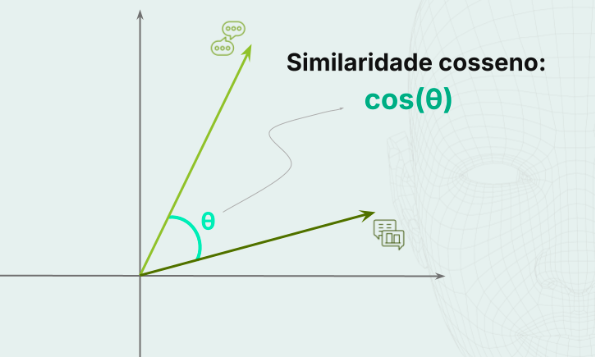

## Utilizando o modelo do Google

In [ ]:
import tensorflow_hub as hub
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
modulo_url = 'https://tfhub.dev/google/universal-sentence-encoder/4'

model = hub.load(modulo_url)
model

<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject at 0x7f18dbaff110>

In [ ]:
# não precisa da lematização para esse modelo
reviews = df['tratamento_3'].tolist()
reviews_emb = model(reviews)
reviews_emb

<tf.Tensor: shape=(31474, 512), dtype=float32, numpy=
array([[ 0.04775169,  0.01094663, -0.0541508 , ...,  0.09078011,
        -0.02599917, -0.09261213],
       [-0.00746649, -0.06605157, -0.04505714, ...,  0.05561579,
        -0.02624756, -0.07801282],
       [-0.00820429,  0.04282852, -0.02907449, ...,  0.07496072,
        -0.06071885, -0.07618523],
       ...,
       [ 0.02074313, -0.0543616 , -0.06415588, ...,  0.0719423 ,
         0.0105929 , -0.07603392],
       [-0.04131037, -0.03054746,  0.01322938, ...,  0.06785525,
        -0.0252889 , -0.07106064],
       [ 0.05717909, -0.05808825, -0.02038886, ...,  0.07339787,
        -0.06409648, -0.08014238]], dtype=float32)>

In [ ]:
cosine_similarity(reviews_emb)

array([[1.0000002 , 0.61586297, 0.5175547 , ..., 0.5427756 , 0.57541025,
        0.6691027 ],
       [0.61586297, 0.99999994, 0.5666107 , ..., 0.63920605, 0.6011834 ,
        0.6711744 ],
       [0.5175547 , 0.5666107 , 0.9999999 , ..., 0.58997375, 0.6564975 ,
        0.5922985 ],
       ...,
       [0.5427756 , 0.63920605, 0.58997375, ..., 1.        , 0.6378722 ,
        0.61628115],
       [0.57541025, 0.6011834 , 0.6564975 , ..., 0.6378722 , 1.0000001 ,
        0.6389235 ],
       [0.6691027 , 0.6711744 , 0.5922985 , ..., 0.61628115, 0.6389235 ,
        1.        ]], dtype=float32)

O Universal Sentence Encoder (USE) é uma ferramenta desenvolvida pelo Google que gera embeddings de sentenças, ou seja, representações numéricas de frases em um espaço vetorial. Diferente dos embeddings de palavras tradicionais, como Word2Vec, o USE cria vetores para sentenças completas, facilitando a captura do contexto e do significado da frase como um todo, o que se torna muito útil para tarefas que exigem a compreensão do sentido geral de um texto.

Para construir esses embeddings, o USE oferece duas arquiteturas:

* uma baseada em Transformers
* outra em Deep Averaging Network (DAN).

A arquitetura de Transformers é mais complexa e precisa, utilizando o mecanismo de atenção para capturar as relações entre palavras, levando em consideração tanto a ordem quanto o contexto das palavras em uma sentença. Já a arquitetura DAN, embora mais simples, utiliza uma média das palavras e bigramas para gerar o embedding, sendo mais rápida e eficiente em termos de computação. Ambas as abordagens produzem embeddings de tamanho fixo, com 512 dimensões, o que facilita o uso dos vetores para comparar sentenças de diferentes comprimentos.

Esses embeddings têm uma propriedade importante: ao converter frases em vetores no mesmo espaço vetorial, o USE permite que sentenças com significados parecidos fiquem próximas umas das outras. Por exemplo, frases como “eu gosto de maçãs” e “eu adoro frutas” terão vetores relativamente próximos, pois compartilham um contexto semelhante relacionado à apreciação de alimentos. Esse cálculo de similaridade pode ser feito facilmente usando medidas como a similaridade de cosseno.

O Universal Sentence Encoder é disponibilizado gratuitamente no TensorFlow Hub, onde devs podem integrá-lo a sistemas de NLP para tarefas como análise de sentimentos, classificação de texto e busca similaridade semântica. A simplicidade de implementação permite que ele seja amplamente utilizado para resolver problemas de similaridade entre sentenças, classificação e outras aplicações que dependem da compreensão do contexto e da semântica de frases completas.

In [ ]:
def sentencas_similares(tema, reviews, reviews_emb, top_n=5):
  tema_emb = model([tema])
  similaridades = cosine_similarity(tema_emb, reviews_emb).flatten()

  indices_similares = np.argsort(-similaridades)
  for idx in indices_similares[:top_n]:
    print(f'Review: {reviews[idx]} - Similaridade: {similaridades[idx]:.4f}')


In [ ]:
sentencas_similares('entrega', reviews, reviews_emb)

Review: eficiente entrega - Similaridade: 0.6829
Review: entrega eficiente - Similaridade: 0.6756
Review: agil entrega - Similaridade: 0.6563
Review: entrega prazo - Similaridade: 0.6473
Review: entrega agil - Similaridade: 0.6471


In [ ]:
sentencas_similares('reputacao loja', reviews, reviews_emb, top_n=10)

Review: pessima loja - Similaridade: 0.7126
Review: loja recomenda - Similaridade: 0.7082
Review: loja honesta - Similaridade: 0.7035
Review: rewcomendo loja - Similaridade: 0.6764
Review: loja eficiente - Similaridade: 0.6699
Review: loja responsavel - Similaridade: 0.6674
Review: otima loja - Similaridade: 0.6589
Review: loja responsabilidade - Similaridade: 0.6540
Review: exelente loja - Similaridade: 0.6532
Review: otimas experiencias loja - Similaridade: 0.6473


## Iniciando a construção da aplicação

In [ ]:
import gradio as gr

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

modulo_url = 'https://tfhub.dev/google/universal-sentence-encoder/4'

model = hub.load(modulo_url)

def tratar_texto(texto):
  texto = re.sub(r'\W', ' ', texto.lower())

  word_tokenize_pt = partial(word_tokenize, language='portuguese')
  tokens = word_tokenize_pt(texto)
  stop_words = set(stopwords.words('portuguese'))
  stop_words.discard('não')
  tokens = [w for w in tokens if w not in stop_words]

  texto_sem_acentos = unidecode.unidecode(' '.join(tokens))
  texto_normalizado = re.sub(r'(?!rr|ss)(.)\1+', r'\1', texto_sem_acentos)
  return texto_normalizado

def process_csv(arquivo, tema):
  df = pd.read_csv(arquivo.name)

  df['review_tratada'] = df['review'].apply(tratar_texto)
  df = df[df['review_tratada']!='']
  df.drop_duplicates(subset=['review_tratada'],inplace=True)

  reviews_emb = model(df['review_tratada'].tolist())
  tema_emb = model([tema])

  similaridades = cosine_similarity(tema_emb, reviews_emb).flatten()

  top_indices = np.argsort(-similaridades)

  similar_reviews = df[['nota_review', 'review']].iloc[top_indices]

  similar_df = similar_reviews.head(200)
  nome_arq = f'reviews_similares_{tema}.csv'
  similar_reviews.to_csv(nome_arq)

  return similar_df, nome_arq

with gr.Blocks() as app:
  with gr.Row():
    gr.Markdown('## Encontrado similaridades nas reviews')

  csv_input = gr.File(label='Envie o csv com reviews', file_types=['.csv'])
  tema_input = gr.Textbox(label='Digite o tema de busca (ex: entrega)')

  botao = gr.Button('Clique para buscar as reviews')

  tabela_output = gr.Dataframe(label='Top 200 reviews similares',  headers=['Nota', 'Reviews'], interactive=False)
  arq_output = gr.File(label='Baixar csv ordenado', interactive=False)

  botao.click(process_csv, inputs=[csv_input, tema_input], outputs=[tabela_output, arq_output])

app.launch()

O Gradio é um pacote de código aberto em Python que permite criar rapidamente uma demonstração ou aplicação web para modelos de machine learning, APIs ou qualquer função em Python. Com ele, é possível compartilhar um link para a demonstração ou aplicação web em questão de segundos, utilizando os recursos integrados de compartilhamento do Gradio. Além disso, não é necessário ter conhecimento em JavaScript, CSS ou experiência em hospedagem web.

## Pontos importantes

* Remover stopwords e caracteres especiais;
* Aplicar a normalização das palavras, remoção de acentos e repetição de letras;
* Avaliar as necessidades de ajustes nos conjuntos de texto;
* Simplificar palavras para sua forma básica com a técnica de Lematização.
* Investigar pontos de melhoria nos resultados do modelo Doc2Vec;
* Parametrizar o Doc2Vec buscando uma melhora no desempenho do treinamento;
* Identificar pontos negativos no Doc2Vec e avaliar outra opção de modelo para encontrar a similaridade entre textos.
* Utilizar o Universal Sentence Encoder (USE) para gerar embeddings de frases textuais;
* Aplicar a similaridade do cosseno para encontrar frases mais similares semanticamente;
* Avaliar as frases mais similares definidas pelo USE e dadas pelo valor da distância cosseno.
* Sintetizar todo o projeto desenvolvido para uma aplicação web;
* Utilizar o Gradio como ferramenta para publicação da aplicação desenvolvida em uma interface web;
* Publicar sua aplicação no Spaces obter o link de compartilhamento.